# Spatial Frequency Independence Test

## 방법

Time slot s 고정 → 31일을 i.i.d. replicate으로 사용

$$\hat{\rho}_s(\omega_j, \omega_k) = \mathrm{Corr}_d\left(I_{d,s}(\omega_j),\ I_{d,s}(\omega_k)\right)$$

8개 slot 평균: $\hat{\rho} = \frac{1}{8}\sum_s \hat{\rho}_s$

**Exact Gaussian baseline** (per (d,s) — slot별 missing pattern, day별 spectral density):

$$\mathrm{Cov}^{(d,s)}_{\mathrm{gauss}}(\omega_j,\omega_k) = |S_{jk}^{(d,s)}|^2 + |P_{jk}^{(d,s)}|^2$$

$$S_{jk}^{(d,s)} = \frac{1}{H_q^{(d,s)} \cdot MN} \sum_m \hat{f}_{d,s}(\omega_m)\, g^{(d,s)}_{dft}[j-m]\, g^{(d,s)*}_{dft}[k-m]$$

전체 평균: $\overline{\mathrm{Cov}}_{\mathrm{gauss}} = \frac{1}{31 \times 8}\sum_{d,s} \mathrm{Cov}^{(d,s)}_{\mathrm{gauss}}$

**Residual** = Empirical − Gaussian baseline = non-Gaussian (trispectrum) 기여  
Residual ≈ 0 → DW 독립성 가정 성립

In [1]:
import sys
sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.fft import fftn
import torch

import GEMS_TCO
from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed

print('imports OK')

imports OK


In [2]:
# ── Data loading ───────────────────────────────────────────────────────────
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]
YEAR      = '2024'
MONTH     = 7
MM_COND   = 8
N_SLOTS   = 8

loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=MM_COND,
    years_=[YEAR],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=True
)

N_DAYS = len(df_map) // N_SLOTS
print(f"{N_DAYS} days | monthly_mean = {monthly_mean:.3f} DU")

daily_hourly_maps = []
for d in range(N_DAYS):
    day_map, _ = loader.load_working_data(
        df_map, monthly_mean=monthly_mean,
        idx_for_datamap=[d * N_SLOTS, d * N_SLOTS + N_SLOTS],
        ord_mm=None, dtype=torch.float64, keep_ori=False
    )
    daily_hourly_maps.append(day_map)

# Grid dims
_t0   = daily_hourly_maps[0][list(daily_hourly_maps[0].keys())[0]]
M     = len(torch.unique(_t0[:, 0]))
N     = len(torch.unique(_t0[:, 1]))
MN    = M * N
DLAT  = 0.044
DLON  = 0.063
print(f"Grid: {M} × {N}")

--- Global Monthly Mean for 2024-7: 257.9726 ---
31 days | monthly_mean = 257.973 DU
Grid: 114 × 159


In [3]:
# ── Frequency selection ────────────────────────────────────────────────────
# 기존 empirical 노트북과 동일
FREQ_BANDS = {
    "Near": [(5, 8),  (5, 9),  (5, 10)],
    "Mid":  [(8, 13), (12, 19),(18, 28)],
    "High": [(35, 55),(44, 68),(54, 77)],
}
FREQ_ALL, BAND_LABELS = [], []
for band, freqs in FREQ_BANDS.items():
    for j in freqs:
        FREQ_ALL.append(j)
        BAND_LABELS.append(band)
K = len(FREQ_ALL)

print(f"{'#':>3}  {'Band':>5}  {'(j1,j2)':>10}  {'λ_lat°':>8}  {'λ_lon°':>8}")
for q, (j, b) in enumerate(zip(FREQ_ALL, BAND_LABELS)):
    print(f"  {q:2d}  {b:5s}  ({j[0]:3d},{j[1]:3d})  {M/j[0]*DLAT:8.3f}  {N/j[1]*DLON:8.3f}")

  #   Band     (j1,j2)    λ_lat°    λ_lon°
   0  Near   (  5,  8)     1.003     1.252
   1  Near   (  5,  9)     1.003     1.113
   2  Near   (  5, 10)     1.003     1.002
   3  Mid    (  8, 13)     0.627     0.771
   4  Mid    ( 12, 19)     0.418     0.527
   5  Mid    ( 18, 28)     0.279     0.358
   6  High   ( 35, 55)     0.143     0.182
   7  High   ( 44, 68)     0.114     0.147
   8  High   ( 54, 77)     0.093     0.130


## Core functions

In [4]:
def _get_field_and_mask(day_map, slot_idx, M, N):
    """slot_idx번째 시간대의 (mean-removed field, obs_mask) 반환."""
    key   = sorted(day_map.keys())[slot_idx]
    t_s   = day_map[key]
    raw   = t_s[:, 2].numpy().reshape(M, N)
    mask  = np.isfinite(raw).astype(float)
    field = np.nan_to_num(raw - np.nanmean(raw), nan=0.0)
    return field, mask


def exact_gaussian_cov_single(field, obs_mask, f_hat_2d, hann, M, N, freq_list):
    """
    ONE spatial field snapshot에 대한 exact Gaussian Cov(I_j, I_k).

    Parameters
    ----------
    field     : (M, N) mean-removed field
    obs_mask  : (M, N) 0/1 observed mask
    f_hat_2d  : (M, N) plug-in spectral density (E[|J|²])
    hann      : (M, N) unnormalized Hann window
    freq_list : list of (j1, j2) tuples, length K

    Returns
    -------
    Cov_gauss : (K, K) exact Gaussian covariance
    I_obs     : (K,)   empirical periodogram values |J(ω_j)|²
    """
    K   = len(freq_list)
    MN  = M * N

    # slot-specific effective taper
    g_eff  = hann * obs_mask
    H_q    = float(np.sum(g_eff ** 2))
    norm_q = 1.0 / (2.0 * np.pi * np.sqrt(H_q))
    g_dft  = fftn(g_eff)          # (M, N) complex

    # empirical periodogram
    F_tap = fftn(g_eff * field)
    I_obs = np.abs(F_tap * norm_q) ** 2
    I_obs_vec = np.array([I_obs[j[0], j[1]] for j in freq_list])

    # exact Gaussian baseline
    m1 = np.arange(M)[:, None]
    m2 = np.arange(N)[None, :]

    Cov_gauss = np.zeros((K, K), dtype=float)
    for i, (j1, j2) in enumerate(freq_list):
        g_j = g_dft[(j1 - m1) % M, (j2 - m2) % N]
        for l, (k1, k2) in enumerate(freq_list):
            g_k_conj = np.conj(g_dft[(k1 - m1) % M, (k2 - m2) % N])
            g_k_pos  = g_dft[(k1 + m1) % M, (k2 + m2) % N]
            S_jk = np.sum(f_hat_2d * g_j * g_k_conj) / (H_q * MN)
            P_jk = np.sum(f_hat_2d * g_j * g_k_pos)  / (H_q * MN)
            Cov_gauss[i, l] = abs(S_jk) ** 2 + abs(P_jk) ** 2

    return Cov_gauss, I_obs_vec

## Main computation

Loop: slot s → (1) plug-in f̂_s from 31 days, (2) per-day exact Cov + I_obs

In [5]:
hann = np.outer(np.hanning(M), np.hanning(N))

# 결과 누적
Cov_gauss_sum    = np.zeros((K, K))
Corr_emp_slots   = []   # per-slot empirical correlation  (8개)
Corr_gauss_slots = []   # per-slot exact Gaussian corr    (8개)

for s in range(N_SLOTS):
    print(f"Slot {s} ...", end='  ')

    # ── Step 1: plug-in f̂_s = mean |J_{d,s}|² over 31 days ───────────────
    f_hat_s = np.zeros((M, N), dtype=float)
    for d in range(N_DAYS):
        field, mask = _get_field_and_mask(daily_hourly_maps[d], s, M, N)
        g_eff  = hann * mask
        H_q    = float(np.sum(g_eff ** 2))
        norm_q = 1.0 / (2.0 * np.pi * np.sqrt(H_q))
        F_tap  = fftn(g_eff * field)
        f_hat_s += np.abs(F_tap * norm_q) ** 2
    f_hat_s /= N_DAYS

    # ── Step 2: per-day exact Cov_gauss + I_obs ────────────────────────────
    I_mat_s       = np.zeros((N_DAYS, K))
    Cov_gauss_s   = np.zeros((K, K))     # slot s 평균 exact Gaussian

    for d in range(N_DAYS):
        field, mask = _get_field_and_mask(daily_hourly_maps[d], s, M, N)
        cov_ds, i_obs = exact_gaussian_cov_single(
            field, mask, f_hat_s, hann, M, N, FREQ_ALL
        )
        Cov_gauss_sum += cov_ds
        Cov_gauss_s   += cov_ds
        I_mat_s[d]     = i_obs

    Cov_gauss_s /= N_DAYS
    std_gs = np.sqrt(np.clip(np.diag(Cov_gauss_s), 1e-30, None))
    Corr_gauss_slots.append(Cov_gauss_s / np.outer(std_gs, std_gs))

    # ── Step 3: empirical correlation for this slot (31 days) ─────────────
    f_vec   = I_mat_s.mean(axis=0)
    I_c     = I_mat_s - f_vec
    cov_emp = (I_c.T @ I_c) / N_DAYS
    std_emp = np.sqrt(np.clip(np.diag(cov_emp), 1e-30, None))
    Corr_emp_slots.append(cov_emp / np.outer(std_emp, std_emp))
    print("done")

# ── Averages ───────────────────────────────────────────────────────────────
Corr_emp_mean   = np.mean(Corr_emp_slots,   axis=0)
Cov_gauss_mean  = Cov_gauss_sum / (N_DAYS * N_SLOTS)
std_g           = np.sqrt(np.clip(np.diag(Cov_gauss_mean), 1e-30, None))
Corr_gauss_mean = Cov_gauss_mean / np.outer(std_g, std_g)
Corr_residual   = Corr_emp_mean - Corr_gauss_mean

print("\nDone.")

Slot 0 ...  done
Slot 1 ...  done
Slot 2 ...  done
Slot 3 ...  done
Slot 4 ...  done
Slot 5 ...  done
Slot 6 ...  done
Slot 7 ...  done

Done.


## Results

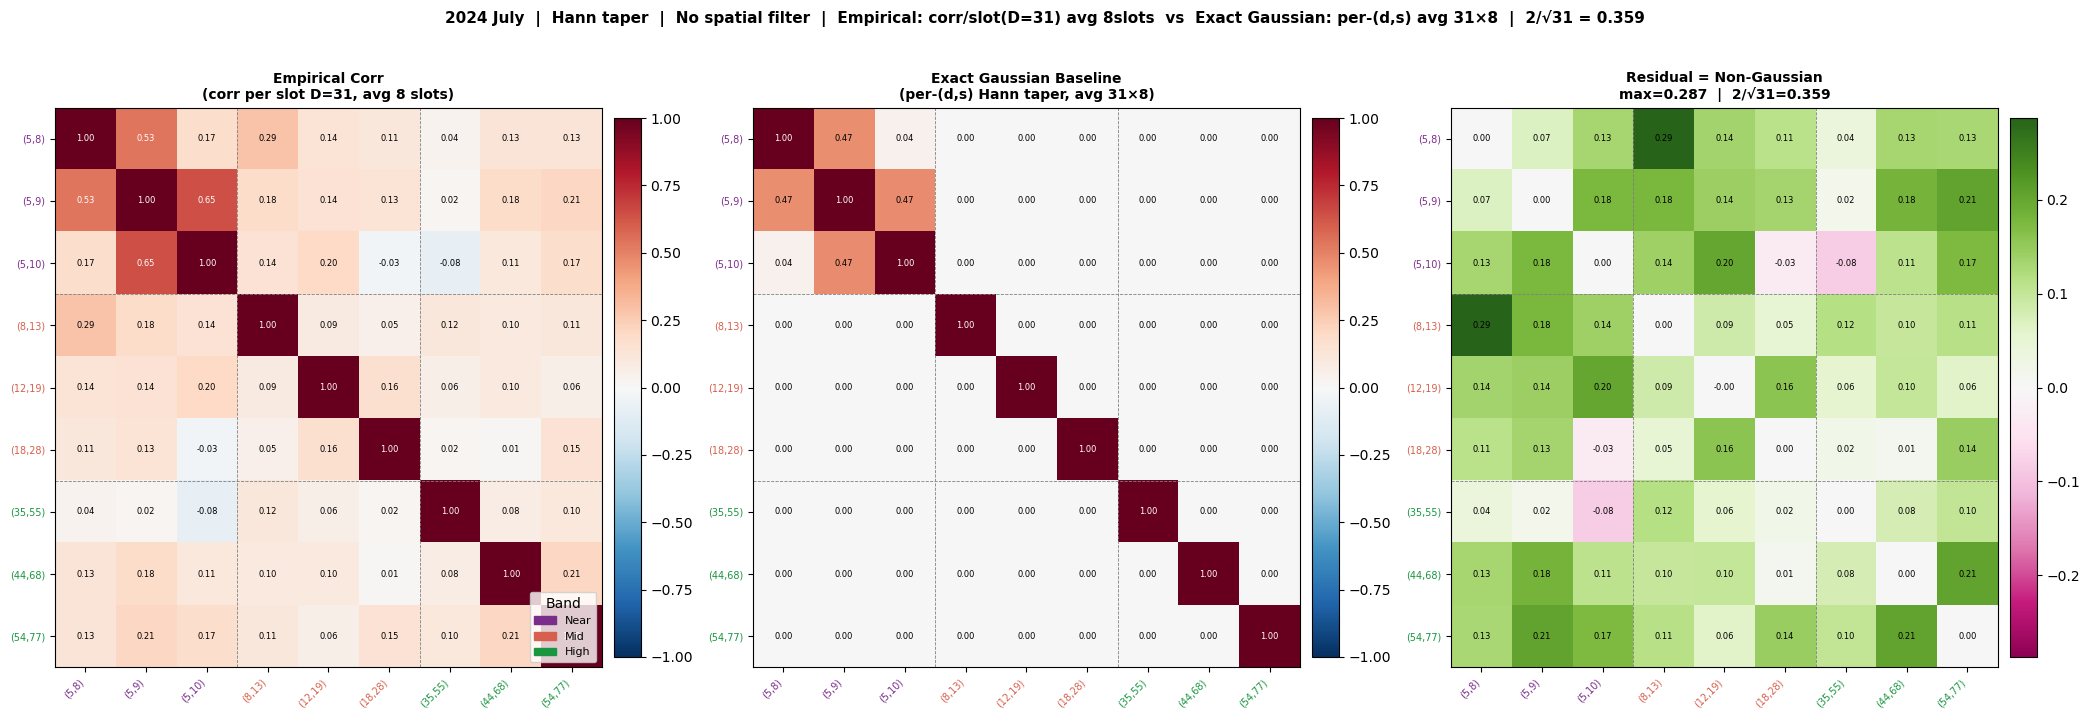

In [6]:
sig_thresh = 2 / np.sqrt(N_DAYS)

band_colors = {"Near": "#7b2d8b", "Mid": "#d6604d", "High": "#1a9641"}
tick_labels = [f"({j[0]},{j[1]})" for j in FREQ_ALL]
tick_colors = [band_colors[b] for b in BAND_LABELS]
SEP = [2.5, 5.5]

def draw_mat(ax, mat, cmap, vmin, vmax, title):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(tick_labels, fontsize=7)
    for q, tc in enumerate(tick_colors):
        ax.get_xticklabels()[q].set_color(tc)
        ax.get_yticklabels()[q].set_color(tc)
    for sep in SEP:
        ax.axhline(sep, color='gray', lw=0.6, ls='--')
        ax.axvline(sep, color='gray', lw=0.6, ls='--')
    for i in range(K):
        for l in range(K):
            ax.text(l, i, f"{mat[i,l]:.2f}", ha='center', va='center',
                    fontsize=6, color='white' if abs(mat[i,l]) > 0.5 else 'black')

rlim = max(0.05, np.abs(Corr_residual).max())

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(
    f"{YEAR} July  |  Hann taper  |  No spatial filter  |  "
    f"Empirical: corr/slot(D=31) avg 8slots  vs  Exact Gaussian: per-(d,s) avg 31×8  |  "
    f"2/√{N_DAYS} = {sig_thresh:.3f}",
    fontsize=11, fontweight='bold', y=1.02
)
draw_mat(axes[0], Corr_emp_mean,   'RdBu_r', -1, 1,
         "Empirical Corr\n(corr per slot D=31, avg 8 slots)")
draw_mat(axes[1], Corr_gauss_mean, 'RdBu_r', -1, 1,
         "Exact Gaussian Baseline\n(per-(d,s) Hann taper, avg 31×8)")
draw_mat(axes[2], Corr_residual,   'PiYG',  -rlim, rlim,
         f"Residual = Non-Gaussian\nmax={rlim:.3f}  |  2/√{N_DAYS}={sig_thresh:.3f}")

handles = [Patch(color=c, label=b) for b, c in band_colors.items()]
axes[0].legend(handles=handles, loc='lower right', fontsize=8, title='Band')
plt.tight_layout()
plt.show()

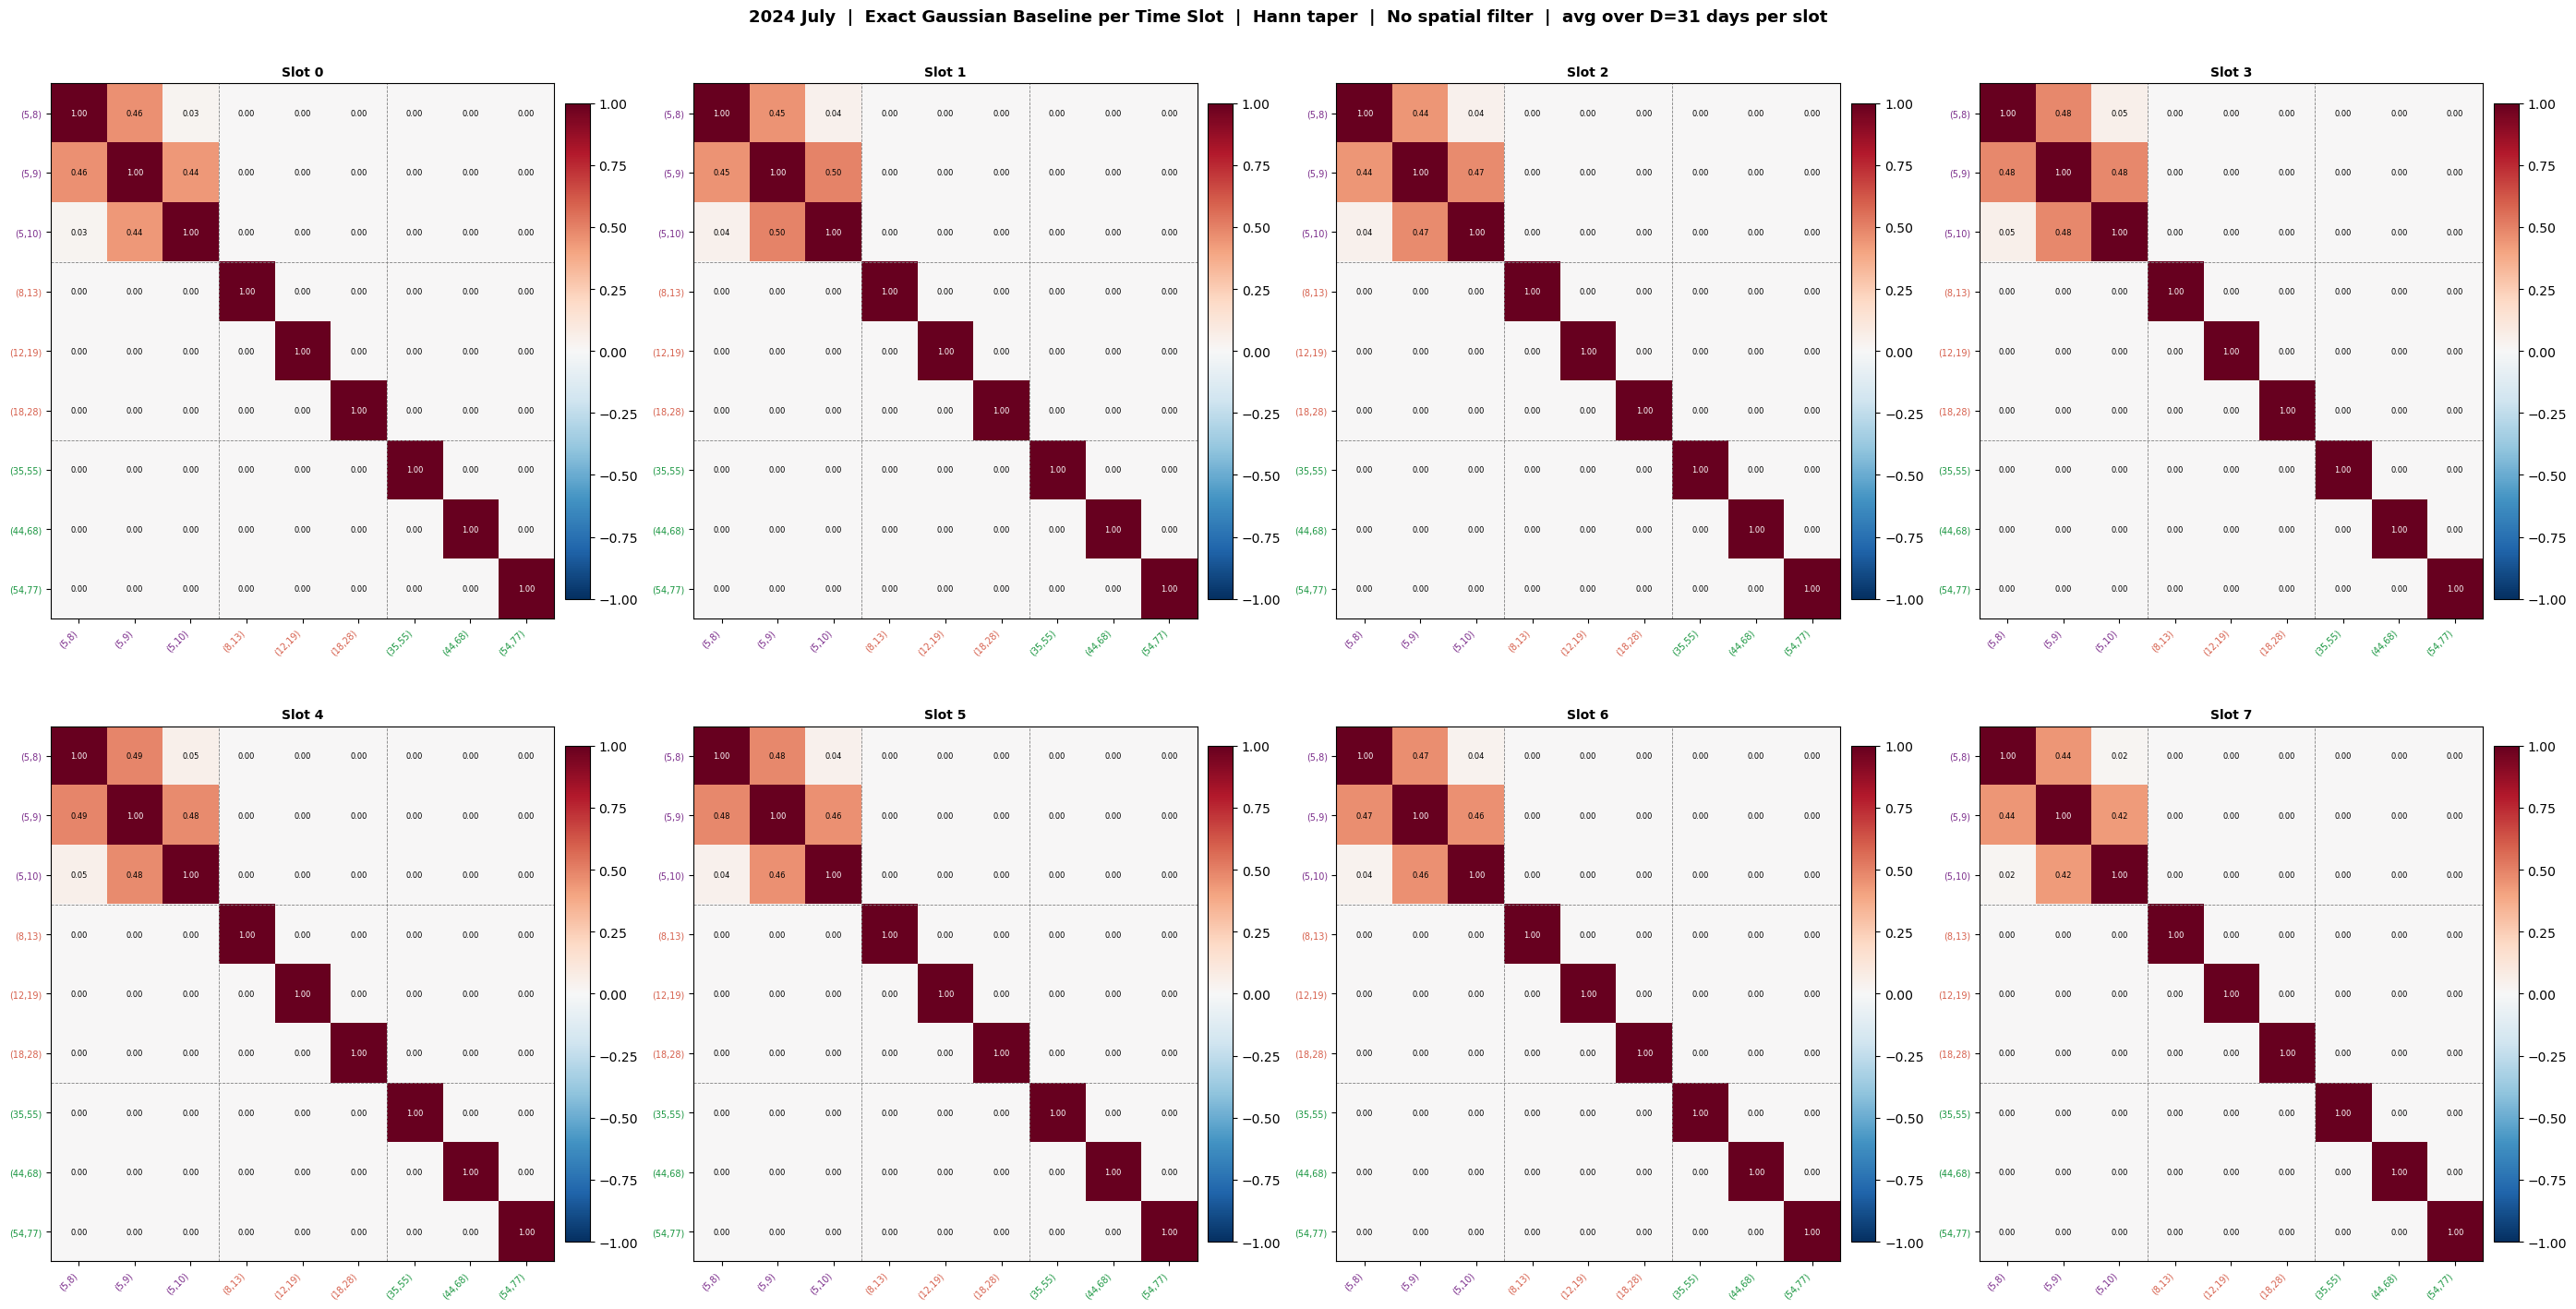

In [7]:
# ── Exact Gaussian baseline per time slot (2×4) ───────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(28, 14))
fig.suptitle(
    f"{YEAR} July  |  Exact Gaussian Baseline per Time Slot  |  "
    f"Hann taper  |  No spatial filter  |  avg over D={N_DAYS} days per slot",
    fontsize=13, fontweight='bold', y=1.01
)
for s, ax in enumerate(axes.ravel()):
    draw_mat(ax, Corr_gauss_slots[s], 'RdBu_r', -1, 1, f"Slot {s}")
plt.tight_layout(h_pad=4.0)
plt.show()

In [8]:
# ── Summary table ──────────────────────────────────────────────────────────
BANDS_IDX  = {b: [i for i, bl in enumerate(BAND_LABELS) if bl == b]
              for b in ["Near", "Mid", "High"]}
BAND_PAIRS = [("Near","Near"),("Near","Mid"),("Near","High"),
              ("Mid","Mid"),("Mid","High"),("High","High")]

print(f"sig threshold 2/√{N_DAYS} = {sig_thresh:.4f}")
print(f"{'Pair':>14}  {'max|emp|':>10}  {'max|gauss|':>12}  {'max|resid|':>12}  {'n_sig_resid':>12}")
print("-"*65)
for b1, b2 in BAND_PAIRS:
    vals_e, vals_g, vals_r = [], [], []
    for i in BANDS_IDX[b1]:
        for l in BANDS_IDX[b2]:
            if b1 == b2 and i == l:
                continue
            vals_e.append(abs(Corr_emp_mean[i, l]))
            vals_g.append(abs(Corr_gauss_mean[i, l]))
            vals_r.append(abs(Corr_residual[i, l]))
    n_sig = sum(v > sig_thresh for v in vals_r)
    flag  = "⚠" if max(vals_r) > sig_thresh else " "
    print(f"  {flag} {b1:5s}×{b2:5s}  {max(vals_e):10.4f}  {max(vals_g):12.4f}  {max(vals_r):12.4f}  {n_sig}/{len(vals_r)}")

sig threshold 2/√31 = 0.3592
          Pair    max|emp|    max|gauss|    max|resid|   n_sig_resid
-----------------------------------------------------------------
    Near ×Near       0.6460        0.4701        0.1759  0/6
    Near ×Mid        0.2879        0.0010        0.2872  0/9
    Near ×High       0.2062        0.0006        0.2057  0/9
    Mid  ×Mid        0.1589        0.0006        0.1584  0/6
    Mid  ×High       0.1452        0.0004        0.1449  0/9
    High ×High       0.2053        0.0002        0.2051  0/6


---\n## No taper (rectangular window)\n\n`g_eff = obs_mask` (Hann 없음) — 동일한 방법론으로 반복

In [9]:
no_taper = np.ones((M, N))   # rectangular window

Cov_gauss_sum_nt    = np.zeros((K, K))
Corr_emp_slots_nt   = []
Corr_gauss_slots_nt = []

for s in range(N_SLOTS):
    print(f"Slot {s} ...", end='  ')

    # plug-in f̂_s (no taper)
    f_hat_s_nt = np.zeros((M, N), dtype=float)
    for d in range(N_DAYS):
        field, mask = _get_field_and_mask(daily_hourly_maps[d], s, M, N)
        g_eff  = no_taper * mask
        H_q    = float(np.sum(g_eff ** 2))
        norm_q = 1.0 / (2.0 * np.pi * np.sqrt(H_q))
        F_tap  = fftn(g_eff * field)
        f_hat_s_nt += np.abs(F_tap * norm_q) ** 2
    f_hat_s_nt /= N_DAYS

    # per-day exact Cov_gauss + I_obs
    I_mat_s_nt     = np.zeros((N_DAYS, K))
    Cov_gauss_s_nt = np.zeros((K, K))

    for d in range(N_DAYS):
        field, mask = _get_field_and_mask(daily_hourly_maps[d], s, M, N)
        cov_ds, i_obs = exact_gaussian_cov_single(
            field, mask, f_hat_s_nt, no_taper, M, N, FREQ_ALL
        )
        Cov_gauss_sum_nt += cov_ds
        Cov_gauss_s_nt   += cov_ds
        I_mat_s_nt[d]     = i_obs

    Cov_gauss_s_nt /= N_DAYS
    std_gs = np.sqrt(np.clip(np.diag(Cov_gauss_s_nt), 1e-30, None))
    Corr_gauss_slots_nt.append(Cov_gauss_s_nt / np.outer(std_gs, std_gs))

    f_vec   = I_mat_s_nt.mean(axis=0)
    I_c     = I_mat_s_nt - f_vec
    cov_emp = (I_c.T @ I_c) / N_DAYS
    std_emp = np.sqrt(np.clip(np.diag(cov_emp), 1e-30, None))
    Corr_emp_slots_nt.append(cov_emp / np.outer(std_emp, std_emp))
    print("done")

Corr_emp_mean_nt   = np.mean(Corr_emp_slots_nt,   axis=0)
Cov_gauss_mean_nt  = Cov_gauss_sum_nt / (N_DAYS * N_SLOTS)
std_g_nt           = np.sqrt(np.clip(np.diag(Cov_gauss_mean_nt), 1e-30, None))
Corr_gauss_mean_nt = Cov_gauss_mean_nt / np.outer(std_g_nt, std_g_nt)
Corr_residual_nt   = Corr_emp_mean_nt - Corr_gauss_mean_nt

print("\nDone.")

Slot 0 ...  done
Slot 1 ...  done
Slot 2 ...  done
Slot 3 ...  done
Slot 4 ...  done
Slot 5 ...  done
Slot 6 ...  done
Slot 7 ...  done

Done.


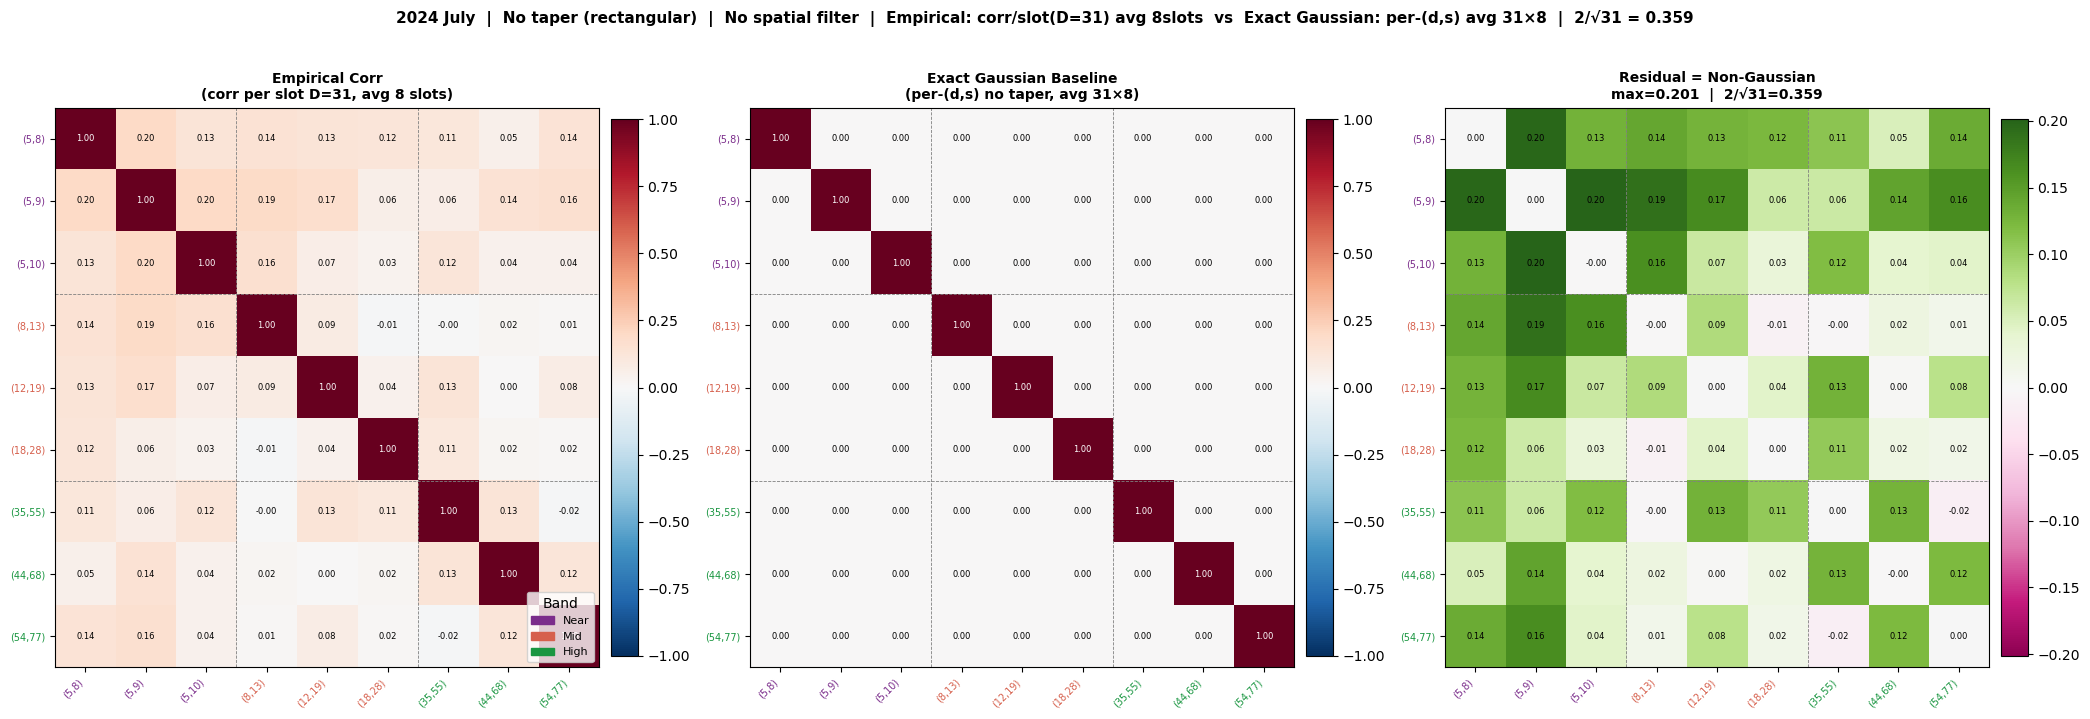

In [10]:
rlim_nt = max(0.05, np.abs(Corr_residual_nt).max())

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(
    f"{YEAR} July  |  No taper (rectangular)  |  No spatial filter  |  "
    f"Empirical: corr/slot(D=31) avg 8slots  vs  Exact Gaussian: per-(d,s) avg 31×8  |  "
    f"2/√{N_DAYS} = {sig_thresh:.3f}",
    fontsize=11, fontweight='bold', y=1.02
)
draw_mat(axes[0], Corr_emp_mean_nt,   'RdBu_r', -1, 1,
         "Empirical Corr\n(corr per slot D=31, avg 8 slots)")
draw_mat(axes[1], Corr_gauss_mean_nt, 'RdBu_r', -1, 1,
         "Exact Gaussian Baseline\n(per-(d,s) no taper, avg 31×8)")
draw_mat(axes[2], Corr_residual_nt,   'PiYG',  -rlim_nt, rlim_nt,
         f"Residual = Non-Gaussian\nmax={rlim_nt:.3f}  |  2/√{N_DAYS}={sig_thresh:.3f}")

handles = [Patch(color=c, label=b) for b, c in band_colors.items()]
axes[0].legend(handles=handles, loc='lower right', fontsize=8, title='Band')
plt.tight_layout()
plt.show()

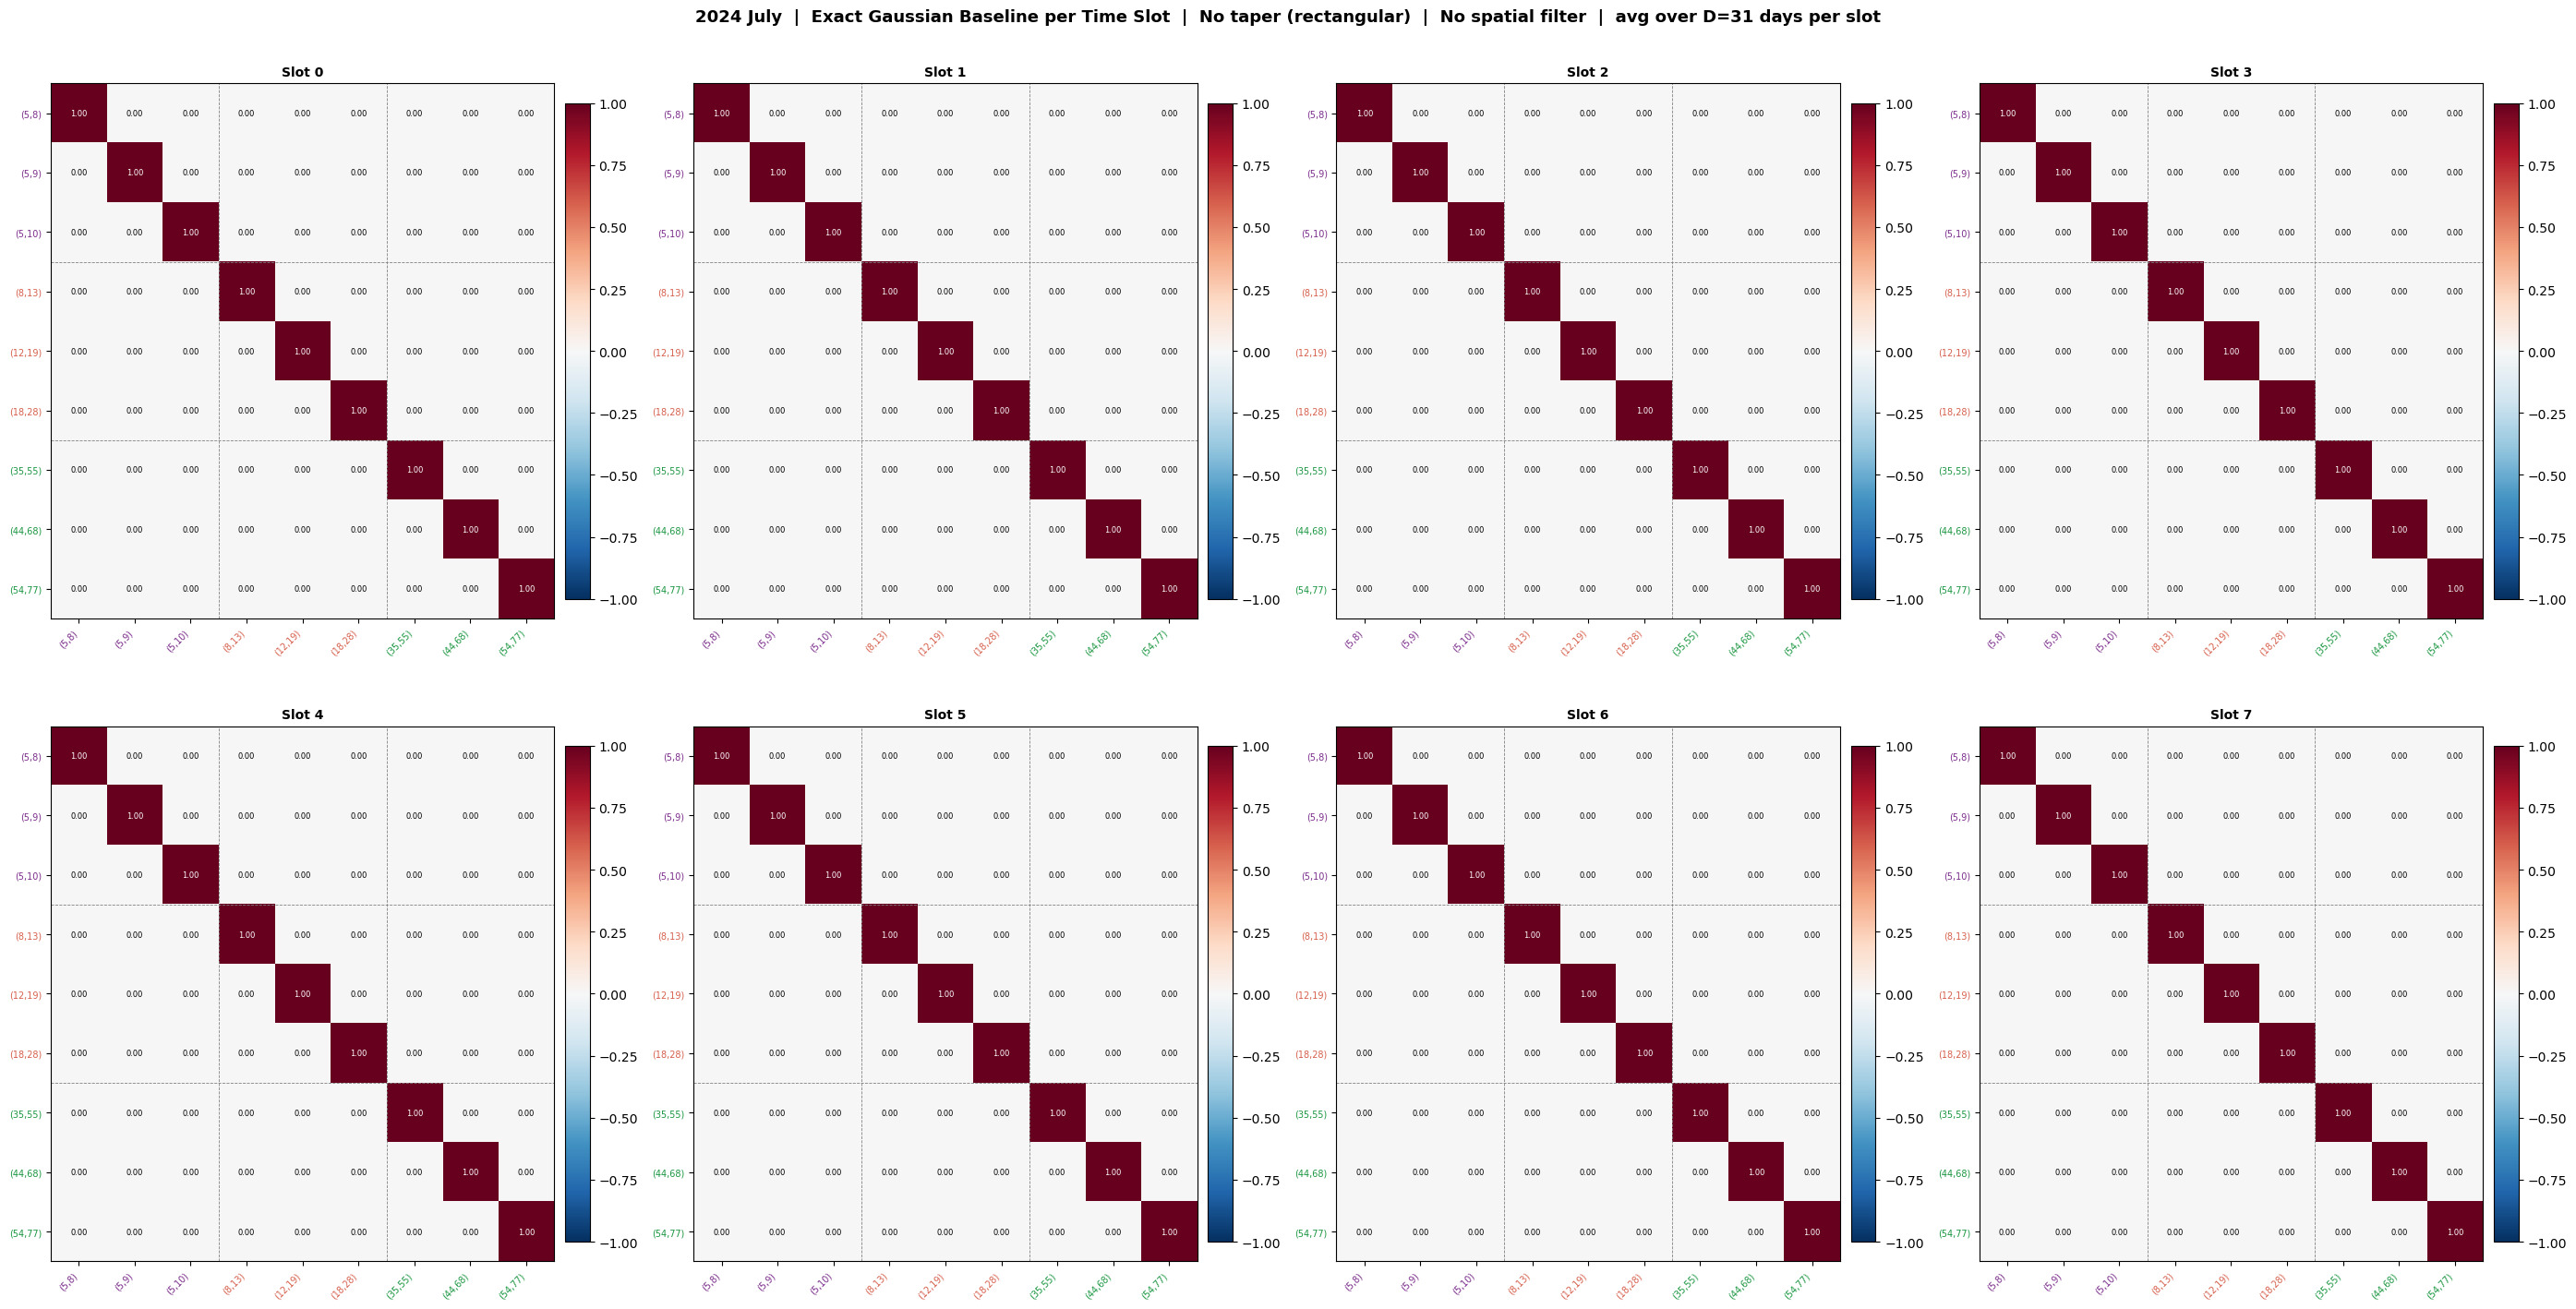

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(28, 14))
fig.suptitle(
    f"{YEAR} July  |  Exact Gaussian Baseline per Time Slot  |  "
    f"No taper (rectangular)  |  No spatial filter  |  avg over D={N_DAYS} days per slot",
    fontsize=13, fontweight='bold', y=1.01
)
for s, ax in enumerate(axes.ravel()):
    draw_mat(ax, Corr_gauss_slots_nt[s], 'RdBu_r', -1, 1, f"Slot {s}")
plt.tight_layout(h_pad=4.0)
plt.show()

---\n## 2-1-1-0 spatial filter + Hann taper\n\n$$Z(i,j) = -2X(i,j) + X(i+1,j) + X(i,j+1)$$\n\nGrid: $(M, N) = (114, 159) \\to (M_d, N_d) = (113, 158)$  \nobs mask: 세 contributing cell 모두 observed인 경우만 유효

In [12]:
def _get_diff_field_and_mask(day_map, slot_idx, M, N):
    """2-1-1-0 first-difference filter on one time slot."""
    field, mask = _get_field_and_mask(day_map, slot_idx, M, N)
    z    = -2.0 * field[:-1, :-1] + field[1:, :-1] + field[:-1, 1:]
    mask_d = mask[:-1, :-1] * mask[1:, :-1] * mask[:-1, 1:]
    return z, mask_d


M_d   = M - 1    # 113
N_d   = N - 1    # 158
hann_d = np.outer(np.hanning(M_d), np.hanning(N_d))

# freq_list 유효성 확인 (모든 인덱스 < M_d//2, N_d//2)
for j1, j2 in FREQ_ALL:
    assert j1 < M_d // 2 and j2 < N_d // 2, f"freq ({j1},{j2}) out of range"
print(f"Filtered grid: {M_d} × {N_d}  — all freqs valid")

Cov_gauss_sum_df    = np.zeros((K, K))
Corr_emp_slots_df   = []
Corr_gauss_slots_df = []

for s in range(N_SLOTS):
    print(f"Slot {s} ...", end='  ')

    # plug-in f̂_s on differenced field
    f_hat_s_df = np.zeros((M_d, N_d), dtype=float)
    for d in range(N_DAYS):
        z, mask_d = _get_diff_field_and_mask(daily_hourly_maps[d], s, M, N)
        g_eff  = hann_d * mask_d
        H_q    = float(np.sum(g_eff ** 2))
        norm_q = 1.0 / (2.0 * np.pi * np.sqrt(H_q))
        F_tap  = fftn(g_eff * z)
        f_hat_s_df += np.abs(F_tap * norm_q) ** 2
    f_hat_s_df /= N_DAYS

    # per-day exact Cov_gauss + I_obs
    I_mat_s_df     = np.zeros((N_DAYS, K))
    Cov_gauss_s_df = np.zeros((K, K))

    for d in range(N_DAYS):
        z, mask_d = _get_diff_field_and_mask(daily_hourly_maps[d], s, M, N)
        cov_ds, i_obs = exact_gaussian_cov_single(
            z, mask_d, f_hat_s_df, hann_d, M_d, N_d, FREQ_ALL
        )
        Cov_gauss_sum_df += cov_ds
        Cov_gauss_s_df   += cov_ds
        I_mat_s_df[d]     = i_obs

    Cov_gauss_s_df /= N_DAYS
    std_gs = np.sqrt(np.clip(np.diag(Cov_gauss_s_df), 1e-30, None))
    Corr_gauss_slots_df.append(Cov_gauss_s_df / np.outer(std_gs, std_gs))

    f_vec   = I_mat_s_df.mean(axis=0)
    I_c     = I_mat_s_df - f_vec
    cov_emp = (I_c.T @ I_c) / N_DAYS
    std_emp = np.sqrt(np.clip(np.diag(cov_emp), 1e-30, None))
    Corr_emp_slots_df.append(cov_emp / np.outer(std_emp, std_emp))
    print("done")

Corr_emp_mean_df   = np.mean(Corr_emp_slots_df,   axis=0)
Cov_gauss_mean_df  = Cov_gauss_sum_df / (N_DAYS * N_SLOTS)
std_g_df           = np.sqrt(np.clip(np.diag(Cov_gauss_mean_df), 1e-30, None))
Corr_gauss_mean_df = Cov_gauss_mean_df / np.outer(std_g_df, std_g_df)
Corr_residual_df   = Corr_emp_mean_df - Corr_gauss_mean_df

print("\nDone.")

Filtered grid: 113 × 158  — all freqs valid
Slot 0 ...  done
Slot 1 ...  done
Slot 2 ...  done
Slot 3 ...  done
Slot 4 ...  done
Slot 5 ...  done
Slot 6 ...  done
Slot 7 ...  done

Done.


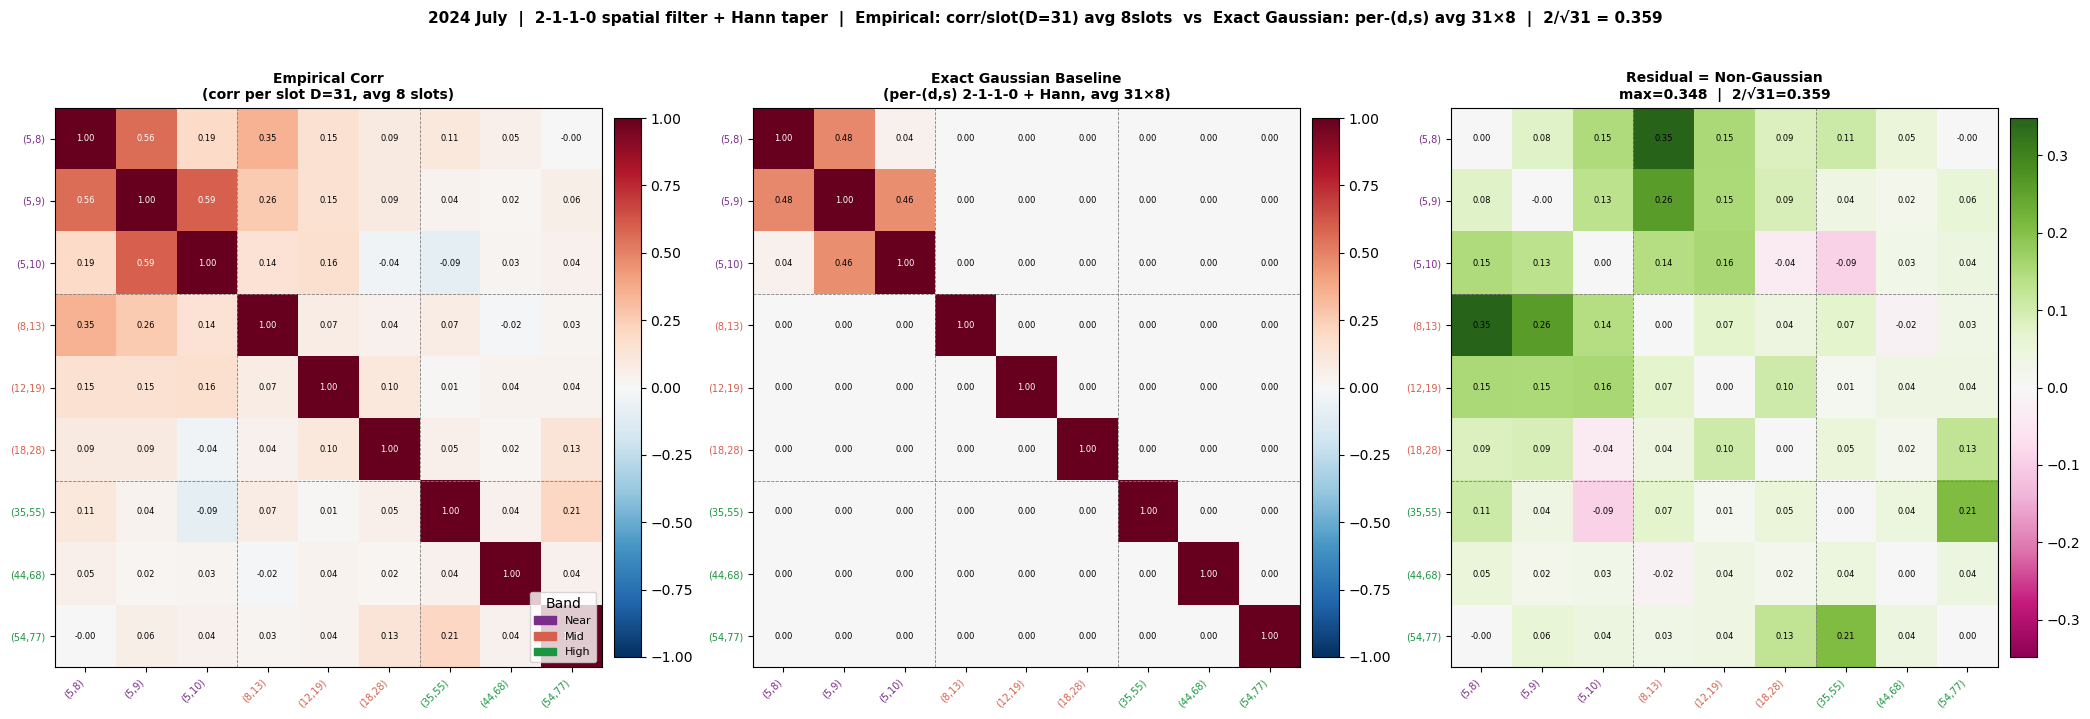

In [13]:
rlim_df = max(0.05, np.abs(Corr_residual_df).max())

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(
    f"{YEAR} July  |  2-1-1-0 spatial filter + Hann taper  |  "
    f"Empirical: corr/slot(D=31) avg 8slots  vs  Exact Gaussian: per-(d,s) avg 31×8  |  "
    f"2/√{N_DAYS} = {sig_thresh:.3f}",
    fontsize=11, fontweight='bold', y=1.02
)
draw_mat(axes[0], Corr_emp_mean_df,   'RdBu_r', -1, 1,
         "Empirical Corr\n(corr per slot D=31, avg 8 slots)")
draw_mat(axes[1], Corr_gauss_mean_df, 'RdBu_r', -1, 1,
         "Exact Gaussian Baseline\n(per-(d,s) 2-1-1-0 + Hann, avg 31×8)")
draw_mat(axes[2], Corr_residual_df,   'PiYG',  -rlim_df, rlim_df,
         f"Residual = Non-Gaussian\nmax={rlim_df:.3f}  |  2/√{N_DAYS}={sig_thresh:.3f}")

handles = [Patch(color=c, label=b) for b, c in band_colors.items()]
axes[0].legend(handles=handles, loc='lower right', fontsize=8, title='Band')
plt.tight_layout()
plt.show()

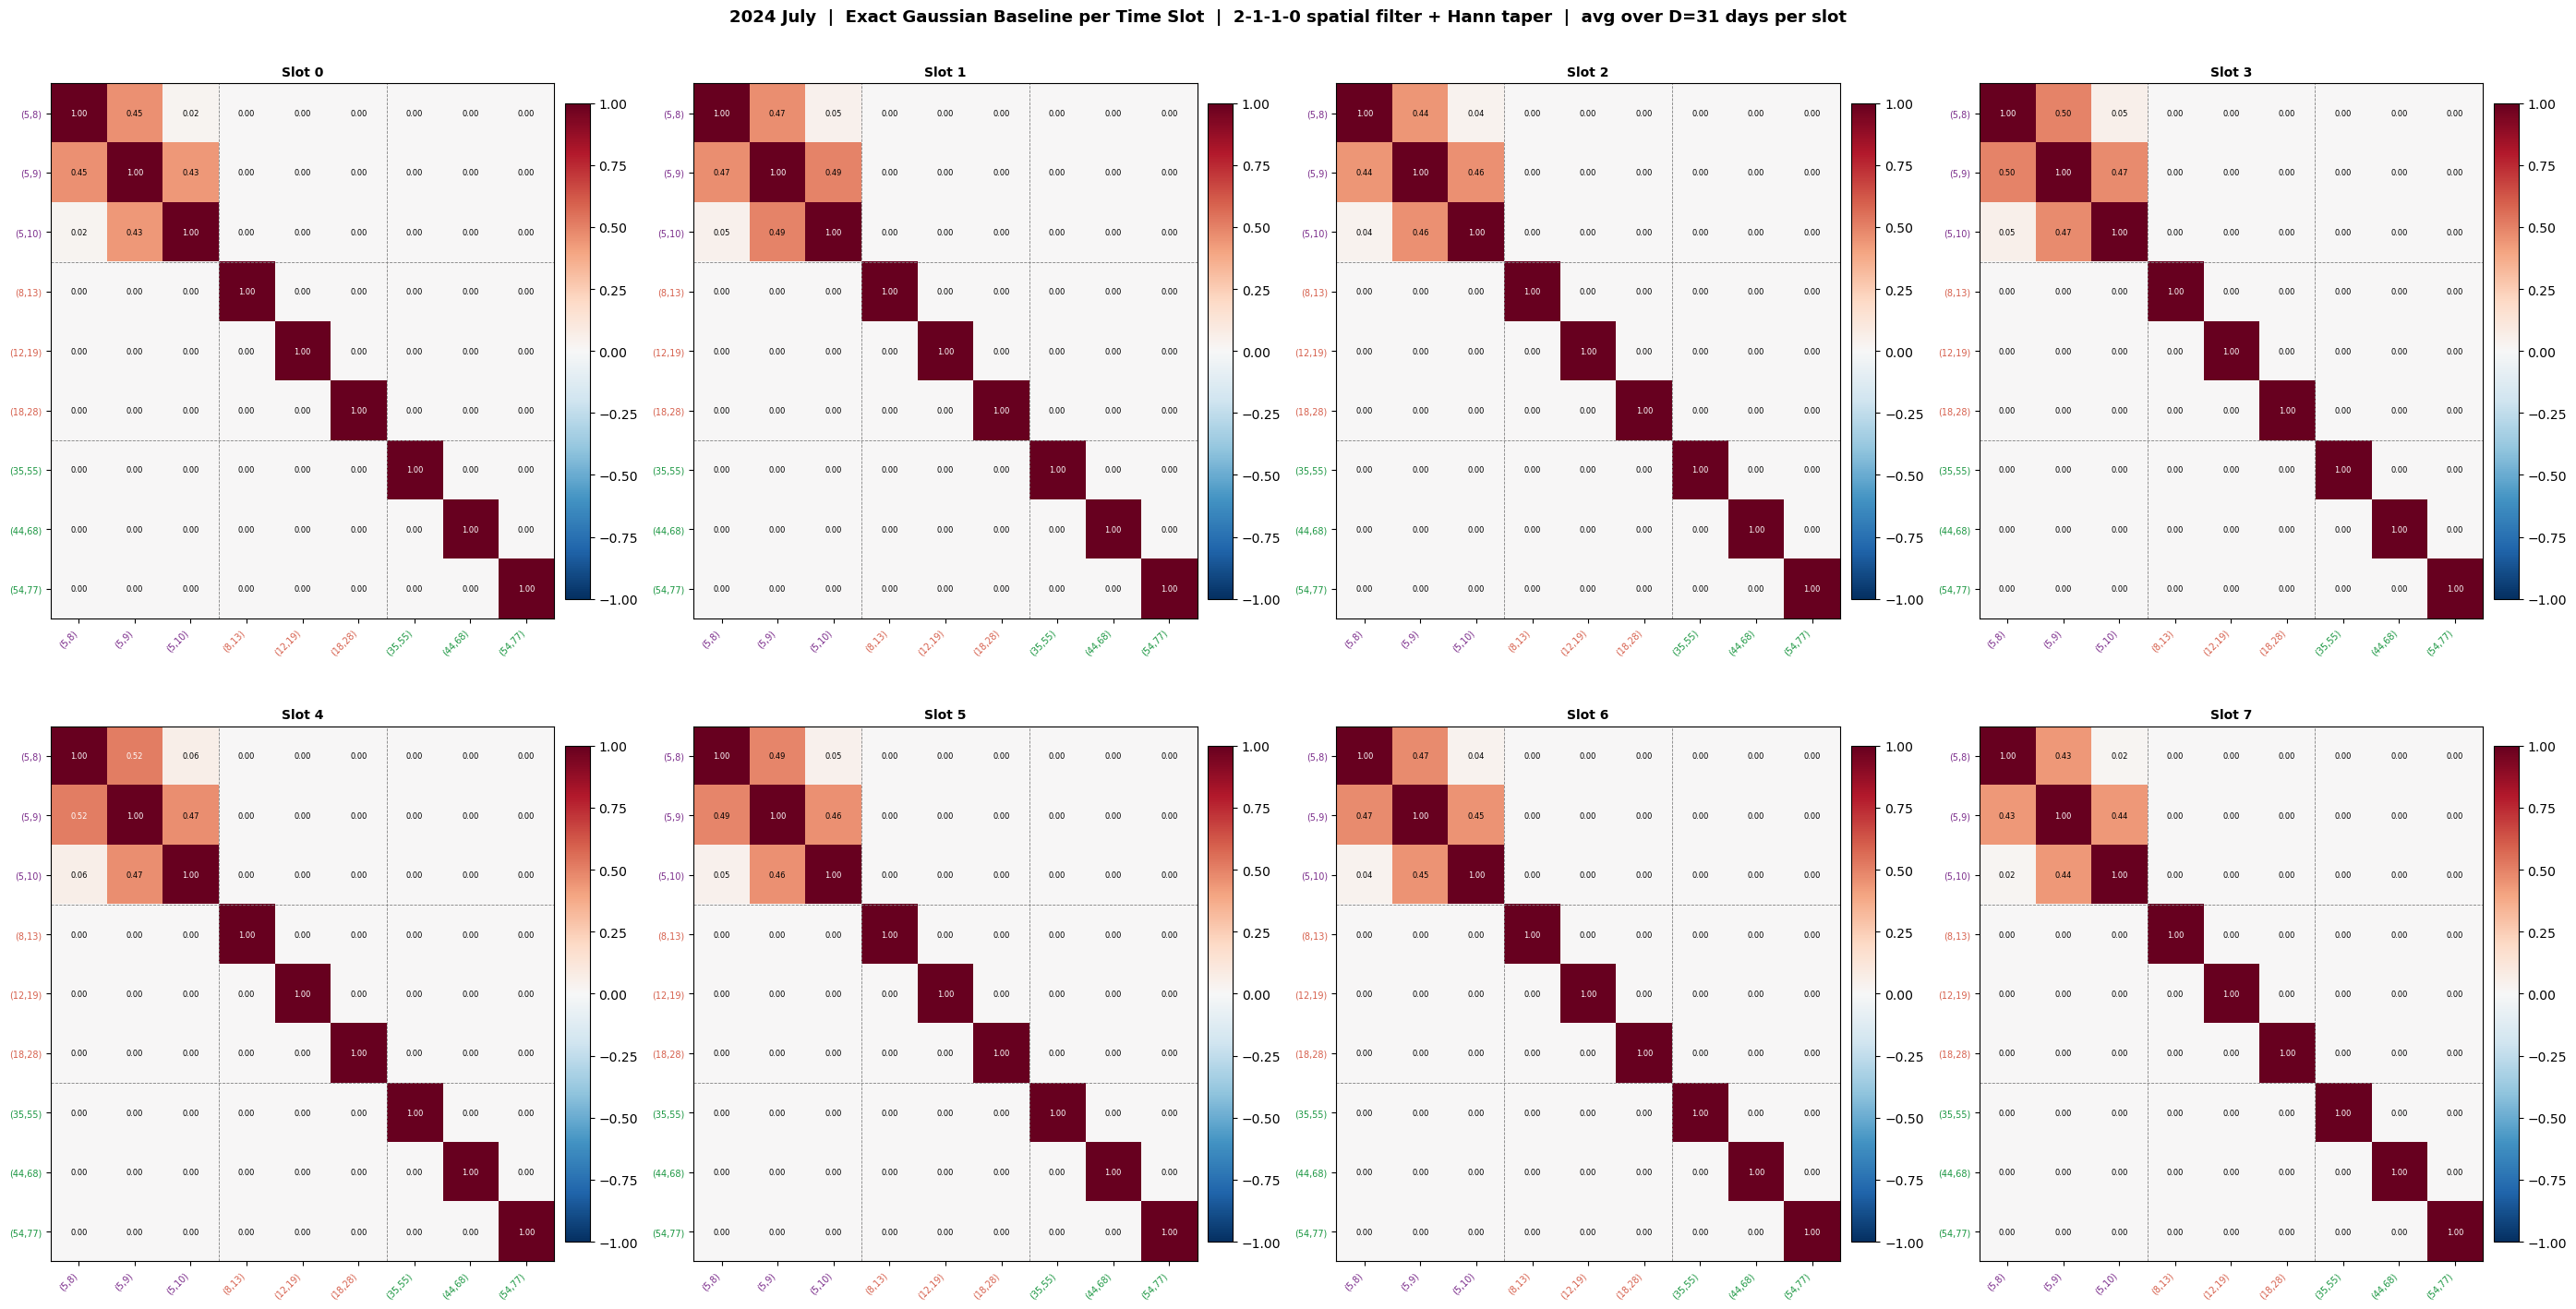

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(28, 14))
fig.suptitle(
    f"{YEAR} July  |  Exact Gaussian Baseline per Time Slot  |  "
    f"2-1-1-0 spatial filter + Hann taper  |  avg over D={N_DAYS} days per slot",
    fontsize=13, fontweight='bold', y=1.01
)
for s, ax in enumerate(axes.ravel()):
    draw_mat(ax, Corr_gauss_slots_df[s], 'RdBu_r', -1, 1, f"Slot {s}")
plt.tight_layout(h_pad=4.0)
plt.show()